# TRABAJO PRÁCTICO INTEGRADOR EJE I -  Fundamentos y Procesamiento Digital de la Señal

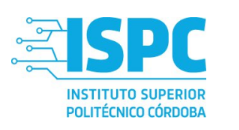


*   Materia: TECNICAS DEL PROCESAMIENTO DEL HABLA
*   Alumnos:
    * GUILLÉN, Jonathan
    * MAJZUM, Maia
    * RAMIREZ, Eglimar
    * OVIEDO, Francisco
    * PICH, Valentina
    * PALOMEQUE Jonathan Manuel
*   Profesor: GIUDICE BOJANICH, Rubén Emmanuel
*   Año: 2026



## PARTE 2: APLICACIÓN PRÁCTICA CON PYTHON

### Configuracion inicial

#### a)  Instalaciond e librerias

In [ ]:
!pip install librosa numpy matplotlib scipy pandas seaborn

#### b) Importación de Modulos

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import pandas as pd
import seaborn as sns
from scipy import signal
from IPython.display import Audio, display
from scipy.interpolate import interp1d
from scipy.signal import resample
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#### c) Configuración de Graficos

In [ ]:
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)

print("Entorno configurado correctamente")

Entorno configurado correctamente


## Ejercicio 2.1: Generación y Análisis de Señales Sintéticas

Generarás tres señales diferentes para estudiar los efectos del muestreo
y cuantización.

Entregables:
* 3 gráficos comparativos (muestreo)
* 1 gráfico comparativo (cuantización)
* Tabla con errores RMS y SNR
* Conclusiones sobre los efectos observados

### a) Generar una señal "analógica" de referencia (muestreada a 100000 Hz)
* Duración: 0.1 segundos
* Frecuencia: 1000 Hz
*  Amplitud: 1.0


In [ ]:
# Parametros de la señal
duracion = 0.1
frecuencia_original = 1000
amplitud = 1.0
fs_analogico = 100000

In [ ]:
# Generar Ejes: Tiempo
tiempo = np.linspace(0, duracion, int(fs_analogico* duracion), endpoint=False)

In [ ]:
#Generar Onda Senoidal pura (señal analogica simulada)
señal_analogica = amplitud * np.sin(2*np.pi*frecuencia_original * tiempo)

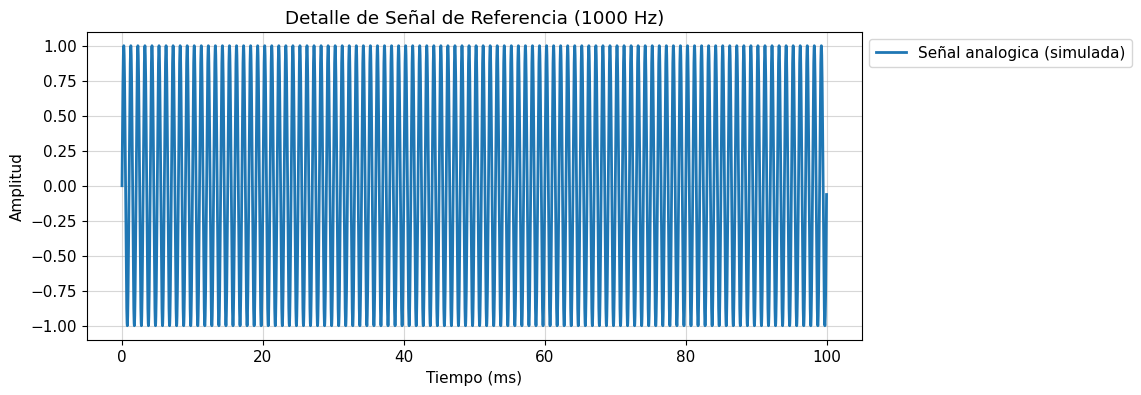

In [ ]:
# Visualizar Onda analogica de referencia
plt.figure(figsize=(10,4))
plt.plot(tiempo*1000, señal_analogica, label ='Señal analogica (simulada)', linewidth=2)
plt.title(f"Detalle de Señal de Referencia ({frecuencia_original} Hz)")
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.5)
plt.show()

### b) Generar una versión muestreada de esta señal a diferentes tasas:
* fs1 = 2500 Hz (muestreo adecuado)
* fs2 = 1500 Hz (cercano al límite de Nyquist)
* fs3 = 800 Hz (submuestreo - aliasing)

In [ ]:
fs_1 = 2500
fs_2 = 1500
fs_3 = 800

### c) Para cada versión muestreada:
* Graficar la señal original (en gris claro) y la muestreada (con stem)
* Calcular y mostrar la frecuencia de Nyquist
* Indicar si hay aliasing o no
* Calcular el error RMS entre la original y la reconstruida

In [ ]:
# Definir funcion de visualizacion de muestreo

def visualizar_muestreo(fs_muestreo):
  """Función que muestrea la señal y compara con la referencia"""

  # Generar tiempos de muestreo
  t_muestreo = np.arange(0, duracion, 1/fs_muestreo)

  # Tomar muestras de la señal analógica
  muestras = amplitud * np.sin(2 * np.pi * frecuencia_original * t_muestreo)

  # Calcular Frecuencia de Nysquist
  f_nyquist = fs_muestreo/2

  # Reconstrucción por interpolación sinc
  señal_reconstruida = resample(muestras, len(tiempo))

  # Error RMS entre señal reconstruida y original
  error_rms = np.sqrt(np.mean((señal_reconstruida - señal_analogica) ** 2))

  # Gráfico comparativo
  plt.figure(figsize=(10, 4))
  plt.plot(tiempo, señal_analogica, 'gray', alpha=0.5, label='Señal original')
  plt.stem(t_muestreo * 1000, muestras, linefmt='b-', markerfmt='bo', basefmt='k-',
  label='Muestras tomadas')
  plt.title(f'Muestreo a {fs_muestreo} Hz')
  plt.xlabel('Tiempo (ms)')
  plt.ylabel('Amplitud')
  plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
  plt.grid(True, alpha=0.3)
  plt.show()

  # Definir si hay Aliasing
  if fs_muestreo < 2 * frecuencia_original:
    print(f"""
    Frecuencia de Nysquit = {f_nyquist} Hz
    Estado Aliasing: ATENCIÓN: fs < 2×f. Está por debajo del límite de Nyquist. ¡Aparecerá aliasing!
    Error RMS calculado: {error_rms:.6f}
    """)
  else:
    print(f"""
    Frecuencia de Nysquit = {f_nyquist} Hz
    Estado Aliasing: No hay Aliasing, es un buen muestreo. La frecuencia de muestreo cumple Nyquist (fs ≥ 2×f).
    Error RMS calculado: {error_rms:.6f}
    """)

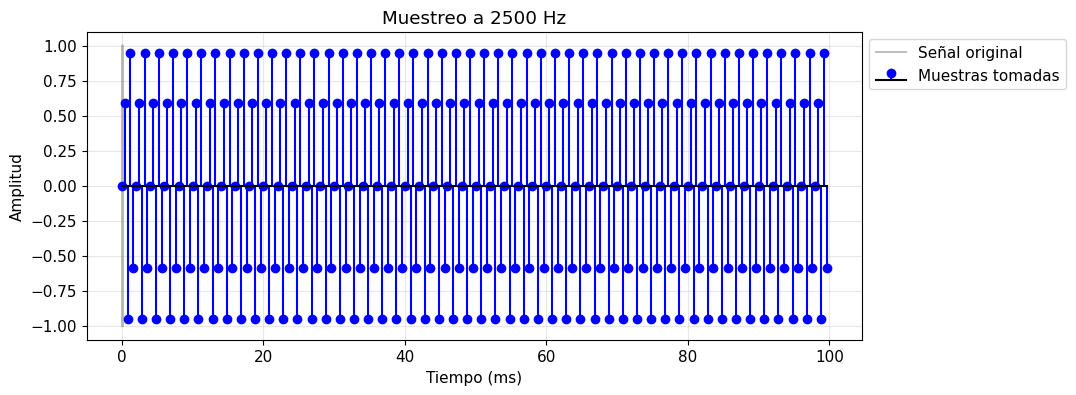


    Frecuencia de Nysquit = 1250.0 Hz
    Estado Aliasing: No hay Aliasing, es un buen muestreo. La frecuencia de muestreo cumple Nyquist (fs ≥ 2×f).
    Error RMS calculado: 0.000000
    


In [ ]:
visualizar_muestreo(fs_1)

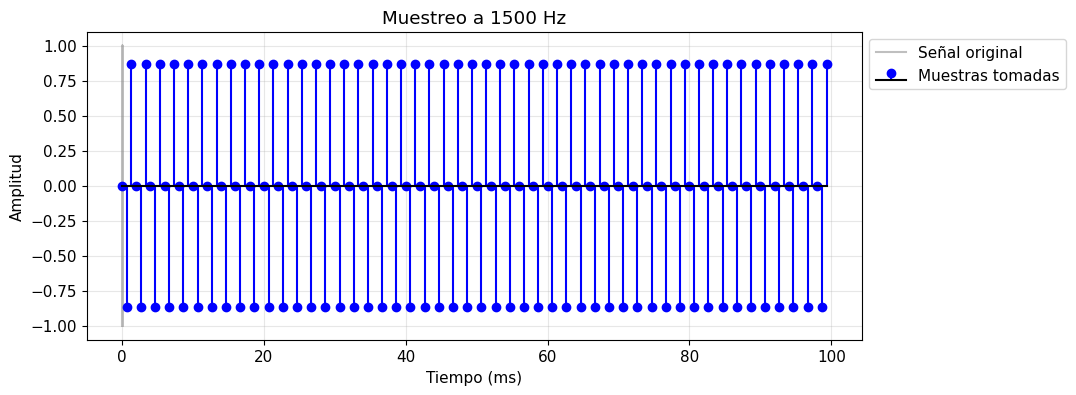


    Frecuencia de Nysquit = 750.0 Hz
    Estado Aliasing: ATENCIÓN: fs < 2×f. Está por debajo del límite de Nyquist. ¡Aparecerá aliasing!
    Error RMS calculado: 1.000000
    


In [ ]:
visualizar_muestreo(fs_2)

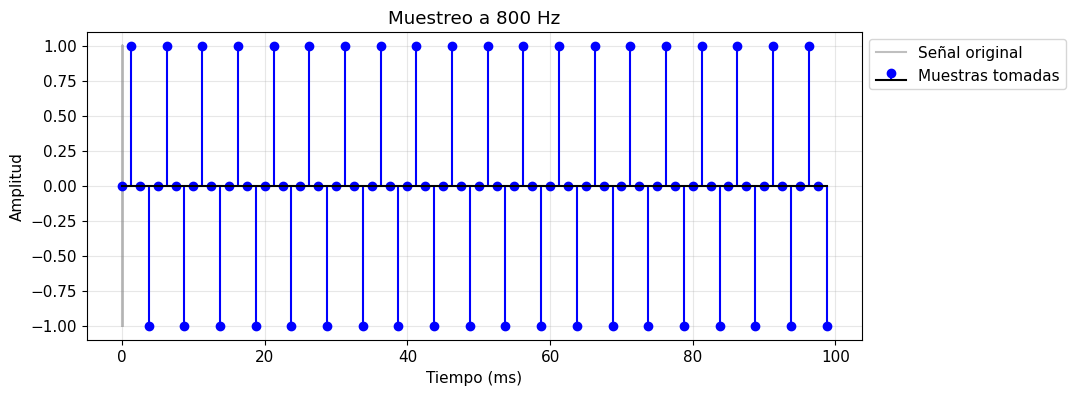


    Frecuencia de Nysquit = 400.0 Hz
    Estado Aliasing: ATENCIÓN: fs < 2×f. Está por debajo del límite de Nyquist. ¡Aparecerá aliasing!
    Error RMS calculado: 1.000000
    


In [ ]:
visualizar_muestreo(fs_3)

### d) Aplicar cuantización a la señal fs1:
* Versión 1: 4 bits
* Versión 2: 8 bits
* Versión 3: 16 bits
* Graficar las tres versiones superpuestas
* Calcular el SNR (relación señal-ruido) de cuantización para cada una

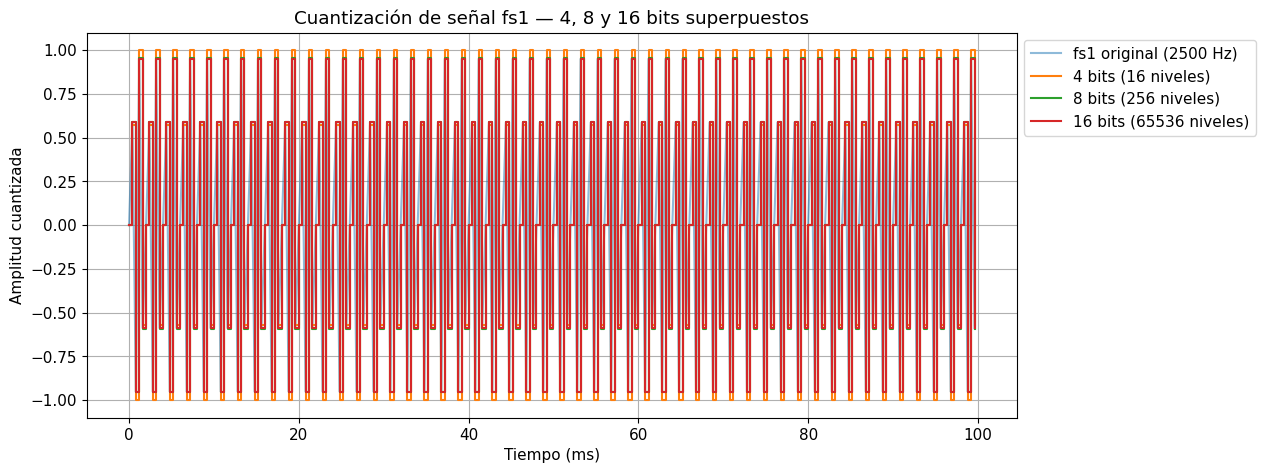

SNR por cantidad de bits:
  4 bits (16 niveles): SNR = 26.72 dB
  8 bits (256 niveles): SNR = 50.74 dB
  16 bits (65536 niveles): SNR = 102.59 dB


In [ ]:
# Cuantización de la señal fs1 (4, 8 y 16 bits)

# Generamos la señal muestreada a fs1 = 2500 Hz
t_fs1 = np.arange(0, duracion, 1/fs_1)
senal_fs1 = amplitud * np.sin(2 * np.pi * frecuencia_original * t_fs1)

def visualizar_cuantizacion(senal, bits):
    # Calculamos el número total de niveles de cuantización basados en los bits
    niveles = 2**bits
    # Cuantizamos la señal: escalamos, redondeamos y volvemos a escalar
    # (niveles/2 - 1) se usa para cuantificación simétrica alrededor de cero

    senal_cuantizada = np.round(senal * (niveles/2 - 1)) / (niveles/2 - 1)
    return senal_cuantizada

configs = [4, 8, 16]
resultados = {}

for bits in configs:
    cuantizada = visualizar_cuantizacion(senal_fs1, bits)
    resultados[bits] = cuantizada

# Gráfico con las tres versiones superpuestas
plt.figure(figsize=(12, 5))
plt.plot(t_fs1 * 1000, senal_fs1, alpha=0.5, linewidth=1.5, label='fs1 original (2500 Hz)')

for bits in configs:
    plt.step(t_fs1 * 1000, resultados[bits], linewidth=1.5,
             label=f'{bits} bits ({2**bits} niveles)', where='post')

plt.title('Cuantización de señal fs1 — 4, 8 y 16 bits superpuestos')
plt.xlabel('Tiempo (ms)')
plt.ylabel('Amplitud cuantizada')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

# Calculo de SNR (relación señal-ruido) de cuantización para cada una
print("SNR por cantidad de bits:")
for bits in configs:
    ruido = senal_fs1 - resultados[bits]
    potencia_señal = np.mean(senal_fs1**2)
    potencia_ruido = np.mean(ruido**2)
    snr = 10 * np.log10(potencia_señal / potencia_ruido)
    print(f"  {bits} bits ({2**bits} niveles): SNR = {snr:.2f} dB")




 ### **Tablas con errores RMS Y SNR**

#### Tabla 1: Errores RMS por Tasa de Muestreo

| Frecuencia de Muestreo (Hz) | Condición de Nyquist | Error RMS |
| :--- | :--- | :--- |
| 2500 | Cumple (Adecuado) | 0 |
| 1500 | No cumple (Aliasing) | 1 |
| 800 | No cumple (Aliasing) | 1 |

<br>

#### Tabla 2: SNR por Niveles de Cuantización (fs = 2500 Hz)

| Bits de Cuantización | Niveles | SNR (dB) |
| :--- | :--- | :--- |
| 4 | 16 | 26.72 |
| 8 | 256 | 50.74 |
| 16 | 65536 | 102.59 |

### **Conclusiones**

-  Al realizar muestreo con diferentes tasas de frecuencia, comprobamos de forma práctica la importancia de respetar el Teorema de Nyquist para no perder información. Al muestrear nuestra señal de 1000 Hz utilizando una tasa de 2500 Hz (superando el límite del doble de la frecuencia original), se logra obtener una reconstrucción perfecta, evidenciada por un error RMS igual a 0. Por el contrario, al forzar un submuestreo con tasas de 1500 Hz y 800 Hz , el error RMS salta al máximo posible (1.0), lo que equivale al 100% de la amplitud de nuestra onda. Confirmando además, que el aliasing no es solo una ligera distorsión, sino una pérdida total de la señal original, ya que el sistema termina dibujando una "onda fantasma" completamente distinta por la falta de muestras suficientes.

- En el análisis de la cuantización, observamos cómo la cantidad de bits afecta directamente la precisión matemática con la que se registra la amplitud de la señal. Al configurar una resolución baja de 4 bits, el sistema solo cuenta con 16 valores posibles para asignar la altura de la onda. Esto lo obliga a realizar redondeos muy bruscos en cada muestra, lo que genera un alto ruido de cuantización evidenciado por un SNR bajo de 26.72 dB. Sin embargo, al aumentar la resolución, comprobamos que la mejora es drástica: con 8 bits (256 niveles) el SNR sube a 50.74 dB , y al llegar a 16 bits (65536 niveles), alcanzamos un SNR excelente de 102.59 dB. Esto demuestra que una mayor cantidad de niveles numéricos reduce drásticamente el error de redondeo, y logra un registro digital mucho más nìtido, limpio y fiel a la señal original.

## Ejercicio 2.2: Creación de Dataset Sintético

Crear un dataset simulado de comandos de voz con características
controladas.


In [ ]:
# Generar 40 muestras de audio (10 por clase)
# Clases: "grave", "medio", "agudo", "ruido"

def generar_dataset_sintetico(n_muestras=10, sr=22050):
    """
    Genera dataset sintético con 4 clases:
    - Clase 0: Tono grave (200-400 Hz)
    - Clase 1: Tono medio (600-1000 Hz)
    - Clase 2: Tono agudo (1500-2500 Hz)
    - Clase 3: ruido blanco filtrado
    """
    dataset = []

    for i in range(n_muestras):
        for clase in range(4):

            # Duración de 1.5 a 2.5 s)
            duracion_real = np.random.uniform(1.5, 2.5)
            t = np.linspace(0, duracion_real, int(sr * duracion_real), endpoint=False)
            # Amplitud
            amplitud = np.random.uniform(0.5, 1.0)
            # Frecuencias según clase
            if clase == 0:  # Grave
                f1 = np.random.uniform(200, 300)
                f2 = np.random.uniform(350, 400)

            elif clase == 1:  # Medio
                f1 = np.random.uniform(600, 750)
                f2 = np.random.uniform(850, 1000)

            elif clase == 2:  # Agudo
                f1 = np.random.uniform(1500, 2000)
                f2 = np.random.uniform(2000, 2500)

            else:  # Ruido blanco filtrado
                ruido = np.random.randn(len(t))
                # Filtro paso-bajo para limitar frecuencias
                b, a = signal.butter(4, 4000/(sr/2), btype='low')
                señal = signal.filtfilt(b, a, ruido)


            # Generar señal con 2 frecuencias de amplitud variable + ruido (SNR entre 10-20 dB)

            if clase != 3:
                  #generar señal tonal
                  señal = amplitud * (
                      0.6 * np.sin(2 * np.pi * f1 * t) +
                      0.3 * np.sin(2 * np.pi * f2 * t))
                  # Agregar ruido usando SNR objetivo
                  # Definir el SNR objetivo (variable)
                  target_snr_db = np.random.uniform(10, 20)
                  # Calcular la potencia de la señal y convertir a dB
                  sig_avg_watts = np.mean(señal**2)
                  sig_avg_db = 10 * np.log10(sig_avg_watts)
                  # Calcular el ruido y convertir a watts
                  noise_avg_db = sig_avg_db - target_snr_db
                  noise_avg_watts = 10 ** (noise_avg_db / 10)
                  # Generar muestras de ruido blanco
                  noise_volts = np.random.normal(0, np.sqrt(noise_avg_watts), len(t))
                  # Sumar el ruido a la señal original
                  señal = señal + noise_volts

            valor_maximo = np.max(np.abs(señal))


            dataset.append({
                'audio': señal,
                'sr': sr,
                'clase': clase,
                'etiqueta': ['grave', 'medio', 'agudo', 'ruido'][clase],
                'duracion': duracion_real,
                'amplitud_max': valor_maximo})

    print(f"✅ Dataset generado: {len(dataset)} muestras, 4 clases")
    return dataset

# Generar dataset
dataset = generar_dataset_sintetico(n_muestras=10)

df = pd.DataFrame([{'clase': m['clase'], 'etiqueta': m['etiqueta']} for m in dataset])
print(df['etiqueta'].value_counts())

✅ Dataset generado: 40 muestras, 4 clases
etiqueta
grave    10
medio    10
agudo    10
ruido    10
Name: count, dtype: int64


## Ejercicio 2.3: Preparación de Datos Crudos

Aplicar el pipeline completo de preprocessing al dataset generado.

Entregables:
* Función preparar_audio() completamente implementada
* DataFrame con metadatos comparativos
* 3 gráficos de visualización
* Análisis de cuánto se redujo el dataset en promedio

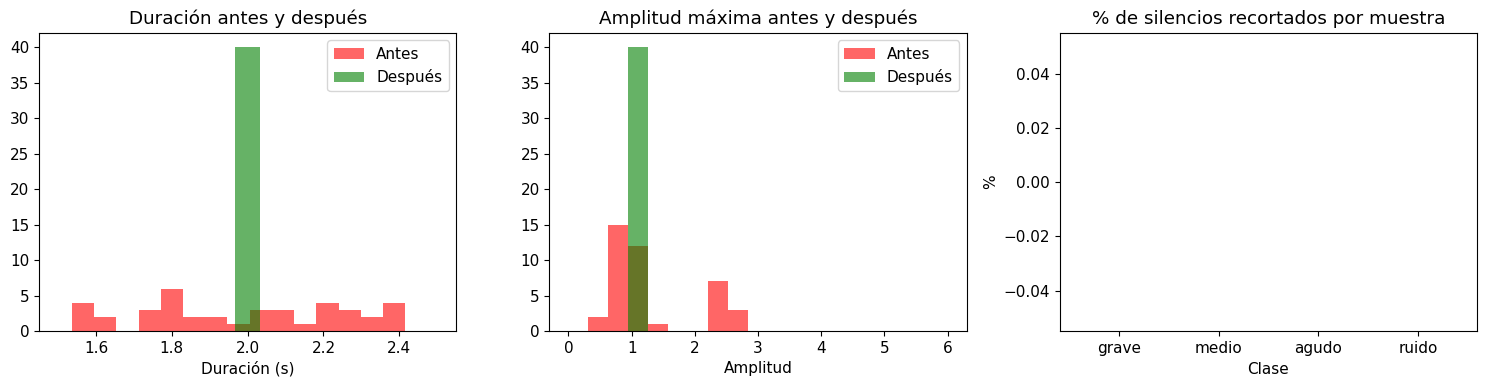

✅ Dataset procesado y guardado
📊 Análisis de reducción del dataset:
  Duración promedio original: 1.99s
  Duración promedio final: 2.00s
  Reducción promedio por trim: 0.00%
  Amplitud promedio original: 1.30
  Amplitud promedio final: 1.00


In [ ]:
# Implementar una función de preprocessing que:
def preparar_audio(audio, sr, duracion_objetivo=2.0, top_db=30):
    """
    Pipeline completo de preparación:
    1. Convertir a mono si es necesario
    2. Recortar silencios (trimming)
    3. Normalizar amplitud (peak normalization)
    4. Remuestrear a 22050 Hz si es necesario
    5. Ajustar duración (pad o crop)
    Retorna: audio_procesado, sr, metadatos
    """
    # Almacenamos metadatos iniciales para comparación posterior
    metadatos = {'dur_original': len(audio)/sr, 'amp_max_original': np.max(np.abs(audio))}

    # 1️⃣ Convertir a mono si es necesario
    if audio.ndim == 2:
        audio = librosa.to_mono(audio)
        print("🔄 Convertido a mono")


    # 2️⃣ Recortar silencios (Trim)
    audio_trim, _ = librosa.effects.trim(audio, top_db=top_db)
    dur_post_trim = len(audio_trim)/sr
    metadatos['porcentaje_trim'] = (1 - dur_post_trim/metadatos['dur_original']) * 100

    # 3️⃣ Normalizar amplitud (Peak Normalization)
    if np.max(np.abs(audio_trim)) > 0:
        audio_norm = audio_trim / np.max(np.abs(audio_trim))
    else:
        audio_norm = audio_trim

    # 4️⃣ Remuestrear a 22050 Hz si es necesario
    target_sr = 22050
    if sr != target_sr:
        audio_norm = librosa.resample(audio_norm, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    # 5️⃣ Ajustar duración (pad o crop)
    samples_obj = int(duracion_objetivo * sr)
    if len(audio_norm) > samples_obj:
        inicio = (len(audio_norm) - samples_obj) // 2
        audio_proc = audio_norm[inicio:inicio + samples_obj]
        metadatos['ajuste_dur'] = 'crop'
    else:
        audio_proc = np.pad(audio_norm, (0, samples_obj - len(audio_norm)), mode='constant')
        metadatos['ajuste_dur'] = 'pad'

    metadatos.update({
        'dur_final': duracion_objetivo,
        'amp_max_final': np.max(np.abs(audio_proc)),
        'sr_final': sr
    })

    return audio_proc, sr, metadatos


# Aplicar la función a todo el dataset
dataset_procesado = []
metadatos_lista = []

for i, muestra in enumerate(dataset):
    audio_proc, sr_proc, meta = preparar_audio(muestra['audio'], muestra['sr'])

    # Guardar metadatos con info de la muestra
    meta['clase'] = muestra['clase']
    meta['etiqueta'] = muestra['etiqueta']
    metadatos_lista.append(meta)

    # Guardar audio procesado
    dataset_procesado.append({
        **muestra,
        'audio': audio_proc,
        'sr': sr_proc
    })

# Crear DataFrame comparativo
df_metadatos = pd.DataFrame(metadatos_lista)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de duraciones antes y después
axes[0].hist(df_metadatos['dur_original'], bins=15, alpha=0.6, label='Antes', color='red')
axes[0].hist(df_metadatos['dur_final'], bins=15, alpha=0.6, label='Después', color='green')
axes[0].set_title('Duración antes y después')
axes[0].set_xlabel('Duración (s)')
axes[0].legend()

# Comparación de amplitudes máximas
bins = np.linspace(0, 6, 20)
axes[1].hist(df_metadatos['amp_max_original'], bins=bins, alpha=0.6, label='Antes', color='red')
axes[1].hist(df_metadatos['amp_max_final'], bins=bins, alpha=0.6, label='Después', color='green')
axes[1].set_title('Amplitud máxima antes y después')
axes[1].set_xlabel('Amplitud')
axes[1].legend()

# Porcentaje de reducción por trimming
axes[2].bar(df_metadatos['etiqueta'], df_metadatos['porcentaje_trim'], color='steelblue')
axes[2].set_title('% de silencios recortados por muestra')
axes[2].set_xlabel('Clase')
axes[2].set_ylabel('%')

plt.tight_layout()
plt.show()

print("✅ Dataset procesado y guardado")

print("📊 Análisis de reducción del dataset:")
print(f"  Duración promedio original: {df_metadatos['dur_original'].mean():.2f}s")
print(f"  Duración promedio final: {df_metadatos['dur_final'].mean():.2f}s")
print(f"  Reducción promedio por trim: {df_metadatos['porcentaje_trim'].mean():.2f}%")
print(f"  Amplitud promedio original: {df_metadatos['amp_max_original'].mean():.2f}")
print(f"  Amplitud promedio final: {df_metadatos['amp_max_final'].mean():.2f}")



### **Análisis**


- El preprocessing no generó reducciones significativas en duración porque el dataset es sintético y no contiene silencios al inicio ni al final (El trim recortó un 0% en promedio).
- La normalización de amplitud sí tuvo impacto: las amplitudes originales variaban entre 0.5 y 1.0 (por diseño), y después del procesamiento todas quedaron en 1.0.
- El pad/crop ajustó todas las muestras a exactamente 2.0 segundos, estandarizando el dataset para su uso en modelos de ML.


## Ejercicio 2.4: Análisis Exploratorio - FFT y Espectros

Analizar el contenido frecuencial de cada clase del dataset.

Entregables:
* 4 gráficos de espectros individuales (uno por clase)
* 1 gráfico de espectros promedio comparativos
* Tabla con frecuencias características por clase
* Conclusiones sobre discriminabilidad

### a) Seleccionar un ejemplo representativo de cada clase, el que tenga RMS más cercano a la media de su clase

In [ ]:
# Función para calcular RMS
def calcular_rms(audio):
    return librosa.feature.rms(y=audio)[0].mean()

# a) Seleccionar ejemplos representativos
ejemplos_representativos = {}

for etiqueta in ['grave', 'medio', 'agudo', 'ruido']:
    muestras_clase = [m for m in dataset_procesado if m['etiqueta'] == etiqueta]
    valores_rms = [calcular_rms(m['audio']) for m in muestras_clase]
    rms_medio = np.mean(valores_rms)

    # Encontrar el índice del más cercano al promedio
    idx_rep = np.argmin([abs(r - rms_medio) for r in valores_rms])
    ejemplos_representativos[etiqueta] = muestras_clase[idx_rep]

### b) Para cada ejemplo:
- Calcular FFT (usar n_fft=2048)
- Graficar el espectro de magnitudes (0-5000 Hz)
- Identificar y marcar los 3 picos principales
- Calcular:
    * Frecuencia fundamental (pico más bajo significativo)
    * Frecuencia del pico más alto
    * Ancho de banda a -20 dB del pico principal

--- Análisis Clase: grave ---
Frecuencia Fundamental: 204.57 Hz
Frecuencia Pico Máximo: 204.57 Hz
Ancho de Banda (-20 dB): 161.50 Hz
Picos principales detectados:
- 204.6 Hz (magnitud: 473.340)
------------------------------


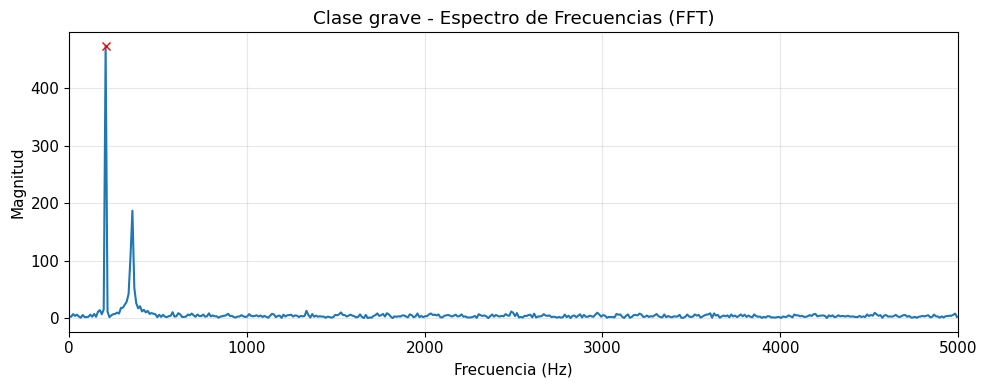

--- Análisis Clase: medio ---
Frecuencia Fundamental: 635.23 Hz
Frecuencia Pico Máximo: 635.23 Hz
Ancho de Banda (-20 dB): 333.76 Hz
Picos principales detectados:
- 635.2 Hz (magnitud: 519.785)
------------------------------


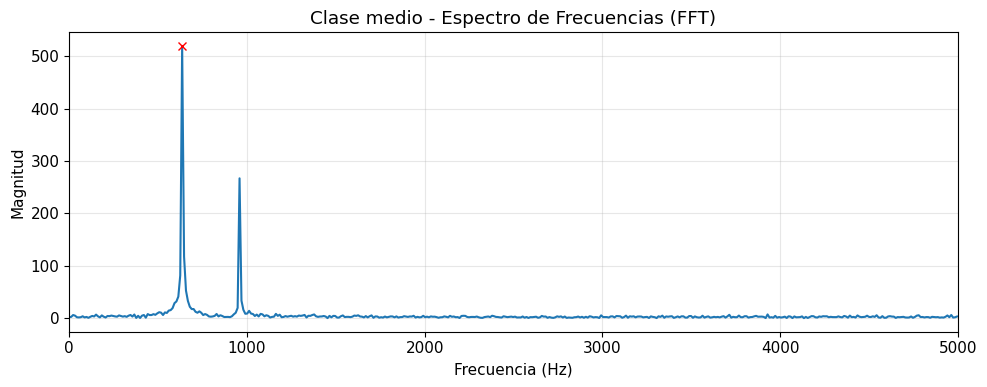

--- Análisis Clase: agudo ---
Frecuencia Fundamental: 1981.05 Hz
Frecuencia Pico Máximo: 1981.05 Hz
Ancho de Banda (-20 dB): 376.83 Hz
Picos principales detectados:
- 1981.1 Hz (magnitud: 484.632)
------------------------------


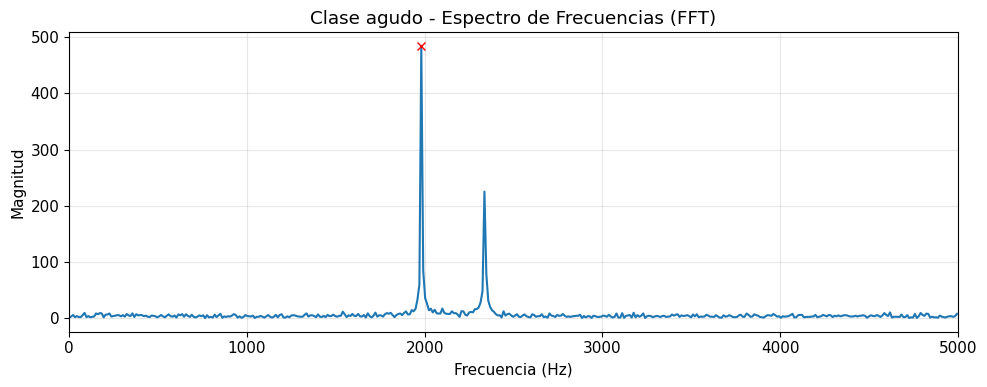

--- Análisis Clase: ruido ---
Frecuencia Fundamental: 43.07 Hz
Frecuencia Pico Máximo: 1270.46 Hz
Ancho de Banda (-20 dB): 4694.24 Hz
Picos principales detectados:
- 1270.5 Hz (magnitud: 42.858)
- 2950.0 Hz (magnitud: 38.331)
- 43.1 Hz (magnitud: 24.416)
------------------------------


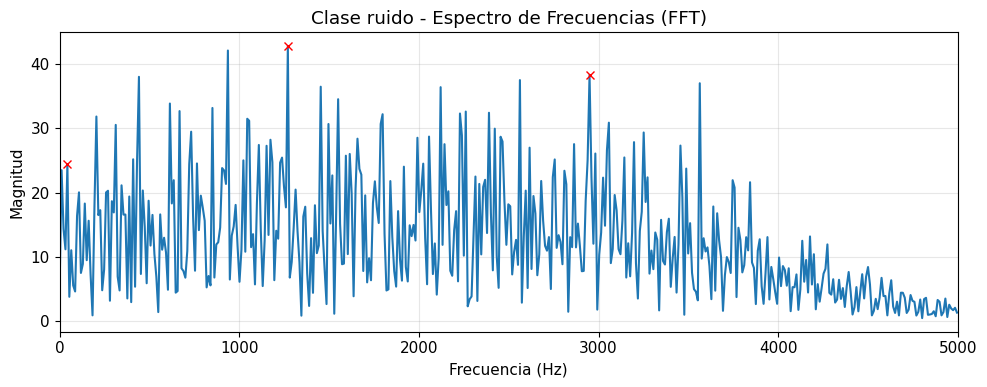

In [ ]:
for i, (etiqueta, muestra) in enumerate(ejemplos_representativos.items()):

    plt.figure(figsize=(10, 4))

    audio = muestra['audio']
    sr = muestra['sr']
    n = len(audio)

    # Calcular FFT
    n_fft = 2048
    X = fft(audio, n_fft)
    mag = np.abs(X[:n_fft//2])
    freqs = fftfreq(n_fft, 1/sr)[:n_fft//2]

    # Filtrar hasta 5000 Hz
    mask = freqs <= 5000
    f_plot = freqs[mask]
    m_plot = mag[mask]

    # Normalizar magnitud en dB
    m_plot_db = 20 * np.log10(m_plot / np.max(m_plot) + 1e-9)

    # Encontrar picos
    peaks, props = find_peaks(m_plot, distance=100, height=np.max(m_plot)*0.1)

    if len(peaks) > 0:
        idx_pico_max = peaks[np.argmax(m_plot[peaks])]
        f_pico_max = f_plot[idx_pico_max]
        f_fundamental = f_plot[peaks[0]]

        umbral_db = -20
        indices_arriba_umbral = np.where(m_plot_db > umbral_db)[0]
        f_low = f_plot[indices_arriba_umbral[0]]
        f_high = f_plot[indices_arriba_umbral[-1]]
        ancho_banda = f_high - f_low

        print(f"--- Análisis Clase: {etiqueta} ---")
        print(f"Frecuencia Fundamental: {f_fundamental:.2f} Hz")
        print(f"Frecuencia Pico Máximo: {f_pico_max:.2f} Hz")
        print(f"Ancho de Banda (-20 dB): {ancho_banda:.2f} Hz")

        # Identificar los 3 picos principales para la consola
        picos_ordenados = peaks[np.argsort(m_plot[peaks])[::-1]]
        top_3 = picos_ordenados[:3]
        print(f"Picos principales detectados:")
        for p in top_3:
            print(f"- {f_plot[p]:.1f} Hz (magnitud: {m_plot[p]:.3f})")
        print("-" * 30)

    # Seleccionar picos para graficar
    sorted_peaks = peaks[np.argsort(m_plot[peaks])][-3:]

    plt.plot(f_plot, m_plot, label=f'Clase: {etiqueta}')
    plt.plot(f_plot[sorted_peaks], m_plot[sorted_peaks], "x", color='red')
    plt.title(f"Clase {etiqueta} - Espectro de Frecuencias (FFT)")
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 5000)
    plt.tight_layout()
    plt.show()

### c) Comparar espectros promedio por clase:
- Calcular el espectro promedio de todas las muestras de cada clase
- Graficar los 4 espectros promedio superpuestos
- Identificar diferencias características entre clases

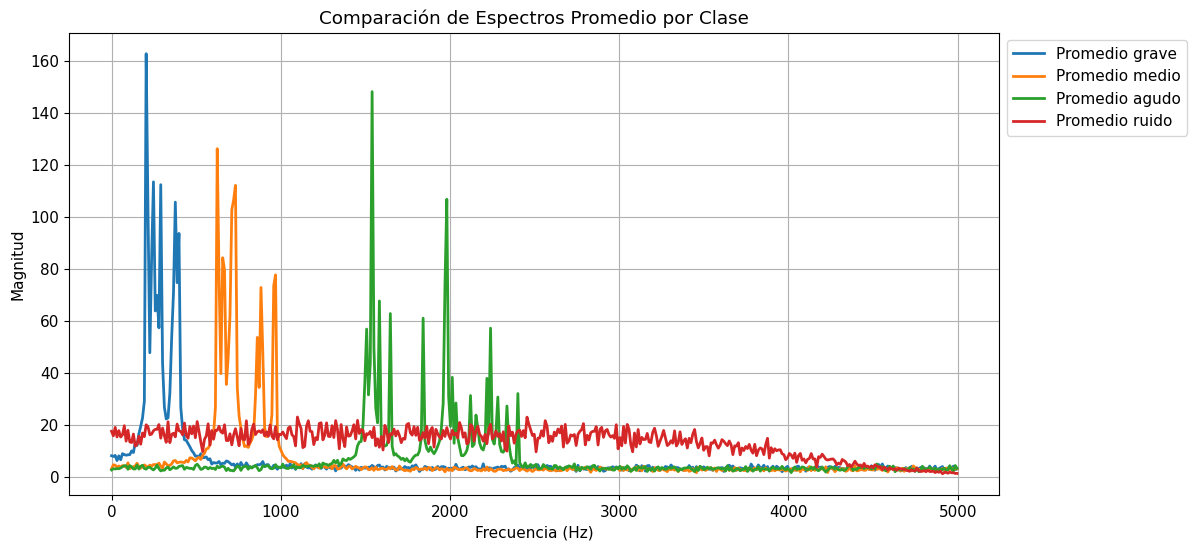

In [ ]:
# Calcular el espectro promedio de todas las muestras de cada clase
# Graficar los 4 espectros promedio superpuestos
# Identificar diferencias características entre clases

plt.figure(figsize=(12, 6))
for etiqueta in ['grave', 'medio', 'agudo', 'ruido']:
  muestras_clase = [m for m in dataset_procesado if m['etiqueta'] == etiqueta]
  if muestras_clase:
    espectros = []
    for m in muestras_clase:
      X = fft(m['audio'], 2048)
      espectros.append(np.abs(X[:1024]))
    promedio = np.mean(espectros, axis=0)
    f = fftfreq(2048, 1/22050)[:1024]
    plt.plot(f[f<=5000], promedio[f<=5000], label=f'Promedio {etiqueta}', linewidth=2)
plt.title("Comparación de Espectros Promedio por Clase")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

### d) Conclusiones del Análisis Frecuencial

1. ¿Se pueden distinguir las clases?

    Sí, las clases tonales "grave", "medio", "agudo" presentan picos definidos en regiones específicas del espectro, mientras que la clase "ruido" la clase ruido tiene energía distribuida uniformemente hasta los 4000 Hz debido al filtro paso-bajo aplicado.

<br>

2. Rangos discriminativos:

* **Grave**: 200 - 400 Hz.
* **Medio**: 600 - 1000 Hz.
* **Agudo**: 1500 - 2500 Hz.
* **Ruido**: Ocupa todo el espectro de forma uniforme hasta los 4000 Hz.

<br>

3. Solapamiento:

    En el dataset sintético actual, el solapamiento es mínimo debido a que las bandas de frecuencia fueron definidas sin intersección. Sin embargo, el ruido añadido crea un 'piso' común que afecta a todas las clases por igual.

 ### **Tabla con frecuencias características por clase**

In [ ]:
resultados_finales = []

for etiqueta, muestra in ejemplos_representativos.items():
    audio = muestra['audio']
    sr = muestra['sr']

    # Calcular FFT (mismo n_fft que el anterior)
    n_fft = 2048
    X = fft(audio, n_fft)
    mag = np.abs(X[:n_fft//2])
    freqs = fftfreq(n_fft, 1/sr)[:n_fft//2]

    # Encontrar picos (sin la restricción de distancia para ser más preciso en la tabla)
    peaks, _ = find_peaks(mag, height=np.max(mag)*0.1)
    sorted_peaks = peaks[np.argsort(mag[peaks])][-3:] # Los 3 más altos
    f_picos = sorted(freqs[sorted_peaks])

    # 1. Frecuencia Fundamental: el más bajo de los significativos
    f_fund = f_picos[0] if len(f_picos) > 0 else 0

    # 2. Frecuencia del pico más alto
    f_max = freqs[np.argmax(mag)]

    # 3. Ancho de banda a -20 dB del pico principal
    idx_max = np.argmax(mag)
    valor_max_db = 20 * np.log10(mag[idx_max])
    umbral_db = valor_max_db - 20
    # Encontrar donde la magnitud cae por debajo del umbral (aproximado)
    mag_db = 20 * np.log10(mag + 1e-9)
    inferior = freqs[mag_db > umbral_db][0]
    superior = freqs[mag_db > umbral_db][-1]
    ancho_banda = superior - inferior


    resultados_finales.append({
        'Clase': etiqueta.upper(),
        'F. Fundamental (Hz)': round(f_fund, 2),
        'F. Pico Máximo (Hz)': round(f_max, 2),
        'Ancho Banda -20dB (Hz)': round(ancho_banda, 2),
        'Picos Detectados': [round(f, 2) for f in f_picos]
    })


# Mostrar la tabla pedida
df_tabla_24 = pd.DataFrame(resultados_finales)
display(df_tabla_24)


,Clase,F. Fundamental (Hz),F. Pico Máximo (Hz),Ancho Banda -20dB (Hz),Picos Detectados
0,GRAVE,204.57,204.57,161.50,"[204.57, 355.3]"
1,MEDIO,635.23,635.23,333.76,"[635.23, 958.23]"
2,AGUDO,1981.05,1981.05,376.83,"[1981.05, 2336.35]"
3,RUIDO,936.69,1270.46,4694.24,"[936.69, 1270.46, 2950.05]"


**Comentarios:**
- Las señales tonales (grave, medio y agudo) tienen una frecuencia dominante clara, lo que indica que son periódicas y estables.

- El ruido se diferencia porque su energía está distribuida
en todas las frecuencias hasta 4000 Hz de forma uniforme.

- Los picos detectados coinciden con las frecuencias usadas en la generación, validando el dataset y el análisis.

- En el ruido, la “frecuencia fundamental” no es real, sino solo el pico de mayor energía.

## Ejercicio 2.5: Extracción de Features y EDA Estadístico

Extraer features y realizar análisis estadístico del dataset.

Entregables:
* DataFrame completo con features
* Tabla de estadísticos descriptivos
* 4 boxplots (uno por feature principal)
* Heatmap de correlación
* Gráfico PCA
* Conclusiones sobre separabilidad de clases

### a) Extracción de Features

In [ ]:

features_lista = []

for muestra in dataset_procesado:
    audio = muestra['audio']
    sr = muestra['sr']

    features = {
        'clase': muestra['clase'],
        'etiqueta': muestra['etiqueta'], # Agregamos etiqueta para facilitar visualización
        'duracion': len(audio) / sr,
        'rms': np.sqrt(np.mean(audio**2)),
        'zcr': librosa.feature.zero_crossing_rate(audio)[0].mean(),
        'spectral_centroid': librosa.feature.spectral_centroid(y=audio, sr=sr)[0].mean(),
        'spectral_bandwidth': librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0].mean(),
        'spectral_rolloff': librosa.feature.spectral_rolloff(y=audio, sr=sr)[0].mean(),
        'spectral_flatness': librosa.feature.spectral_flatness(y=audio)[0].mean()
    }
    features_lista.append(features)

# Convertir a DataFrame
df_features = pd.DataFrame(features_lista)

### b) Estadísticos descriptivos:
- Calcular media,std,min,max por clase para cada feature
- Mostrar tabla resumen

In [ ]:
print("📊 Tabla Resumen: Estadísticos Descriptivos por Clase")

# Agrupamos por clase y calculamos media, std, min y max
stats_resumen = df_features.groupby('etiqueta').agg(['mean', 'std', 'min', 'max'])
display(stats_resumen)

📊 Tabla Resumen: Estadísticos Descriptivos por Clase


clase              duracion                      rms            ...  \
          mean  std min max     mean  std  min  max      mean       std  ...   
etiqueta                                                                 ...   
agudo      2.0  0.0   2   2      2.0  0.0  2.0  2.0  0.395166  0.038264  ...   
grave      0.0  0.0   0   0      2.0  0.0  2.0  2.0  0.392912  0.037344  ...   
medio      1.0  0.0   1   1      2.0  0.0  2.0  2.0  0.400849  0.026352  ...   
ruido      3.0  0.0   3   3      2.0  0.0  2.0  2.0  0.230729  0.012137  ...   

         spectral_bandwidth              spectral_rolloff              \
                        min          max             mean         std   
etiqueta                                                                
agudo           2517.713120  3160.614948      8164.140709  643.127122   
grave           2807.233015  3578.983642      8172.630236  762.435524   
medio           2723.635286  3418.903141      7985.130489  611.719110   
ruido           1036.272899  1287.952664      3397.444437  230.795493   

                                   spectral_flatness                      \
                  min          max              mean       std       min   
etiqueta                                                                   
agudo     6739.026300  8841.359947          0.074567  0.075393  0.012343   
grave     6615.024751  8903.236968          0.082225  0.084057  0.006936   
medio     6732.467336  8973.653017          0.082117  0.061990  0.007284   
ruido     2800.058930  3521.049973          0.035564  0.067893  0.000232   

                    
               max  
etiqueta            
agudo     0.185946  
grave     0.242871  
medio     0.218516  
ruido     0.209767  

[4 rows x 32 columns]

### c) Visualizaciones:
- Boxplot de cada feature comparando las 4 clases
- Pairplot de las 3 features más importantes
- Heatmap de correlación de todas las features

/tmp/ipykernel_39112/1630014693.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='etiqueta', y=col, data=df_features, palette='Set2')
/tmp/ipykernel_39112/1630014693.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='etiqueta', y=col, data=df_features, palette='Set2')
/tmp/ipykernel_39112/1630014693.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='etiqueta', y=col, data=df_features, palette='Set2')
/tmp/ipykernel_39112/1630014693.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed

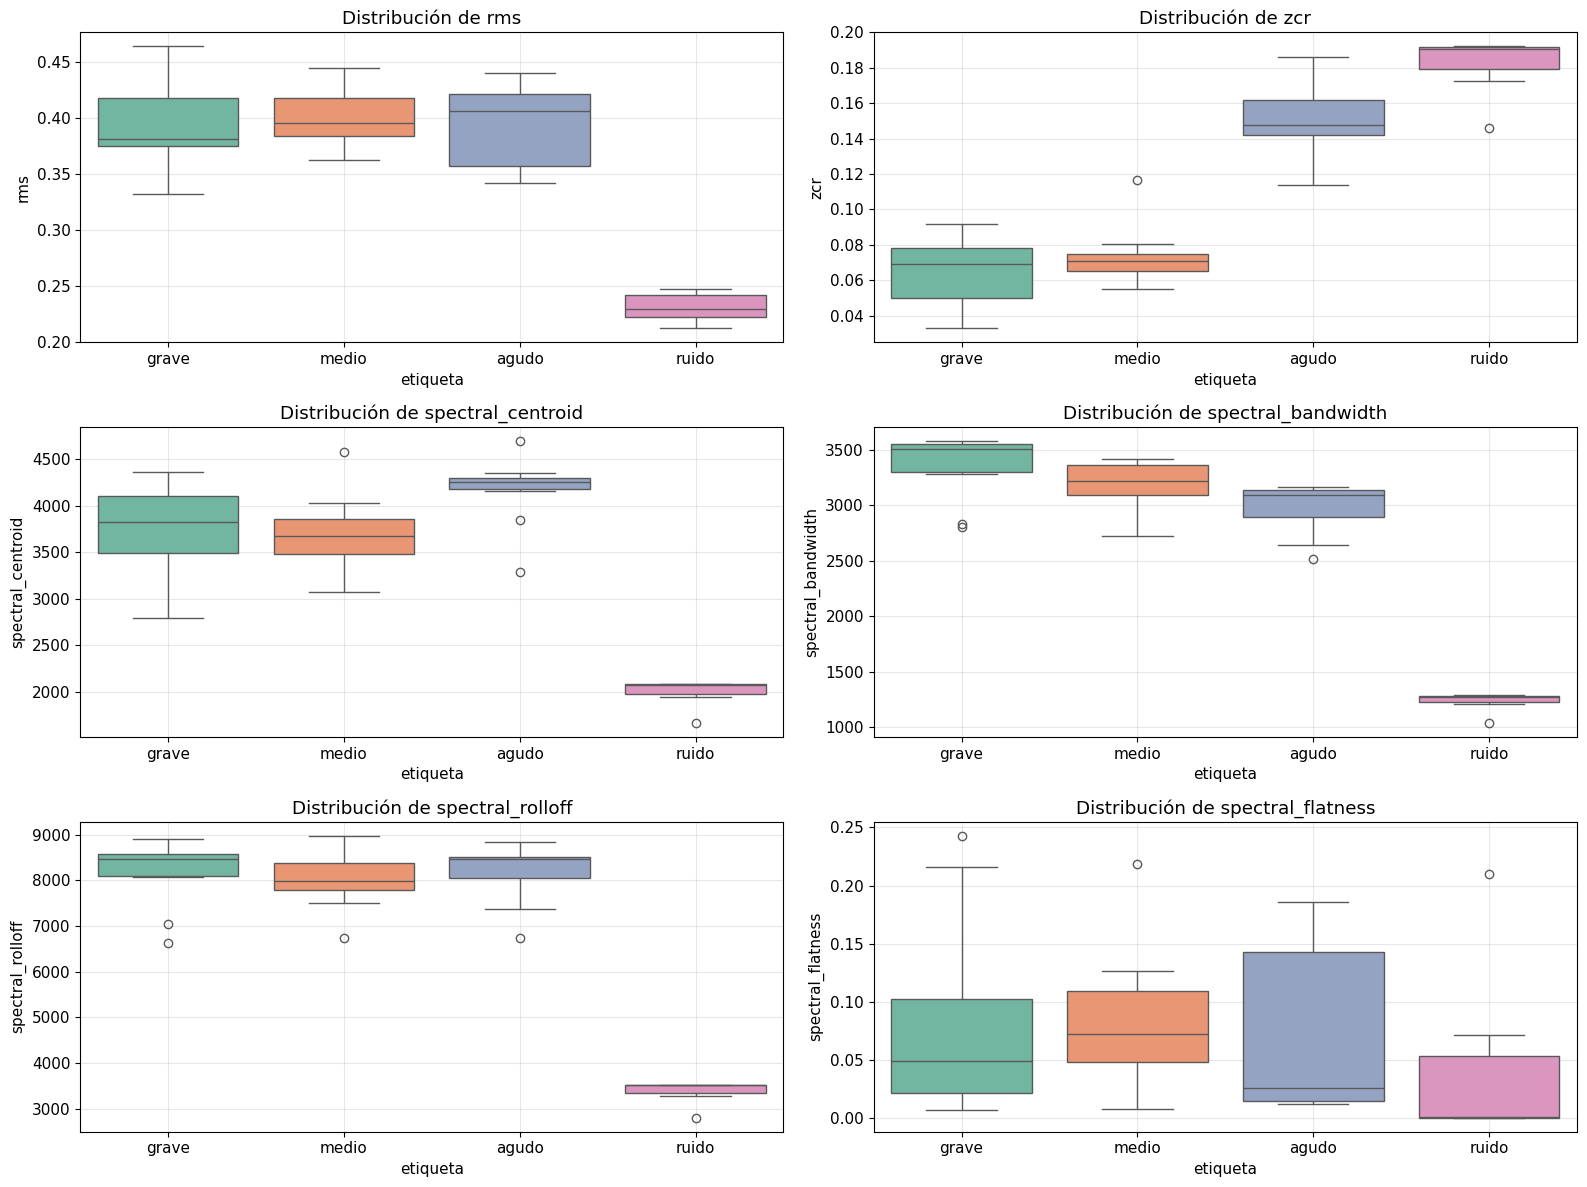

In [ ]:
# C.1. Boxplots de cada feature
cols_para_graficar = ['rms', 'zcr', 'spectral_centroid', 'spectral_bandwidth', 'spectral_rolloff', 'spectral_flatness']
plt.figure(figsize=(16, 12))
for i, col in enumerate(cols_para_graficar):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x='etiqueta', y=col, data=df_features, palette='Set2')
    plt.title(f'Distribución de {col}')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Comentarios:**
- El spectral centroid muestra una separación clara entre las clases tonales, con valores más bajos en la clase grave, intermedios en la clase media y más altos en la clase aguda. La baja superposición indica alta capacidad para diferenciar rangos de frecuencia.
- El zero crossing rate (ZCR) presenta valores más altos en la clase ruido en comparación con las clases tonales, ya que el ruido filtrado sigue
cruzando el cero con mayor frecuencia que una señal periódica.
- La spectral flatness también muestra valores elevados en la clase ruido y bajos en las señales tonales, reflejando la diferencia entre una señal
de energía distribuida y señales estructuradas.
- El spectral bandwidth y el rolloff evidencian mayor solapamiento entre clases y alta correlación con el centroid, lo que indica redundancia en la información que aportan.
- El RMS presenta distribuciones similares entre clases, lo que sugiere baja capacidad discriminativa, en línea con la normalización aplicada durante el preprocessing.
- En conjunto, las features más discriminativas son el spectral centroid, el ZCR y la spectral flatness.

📈 Analizando la interacción entre las features más discriminativas...


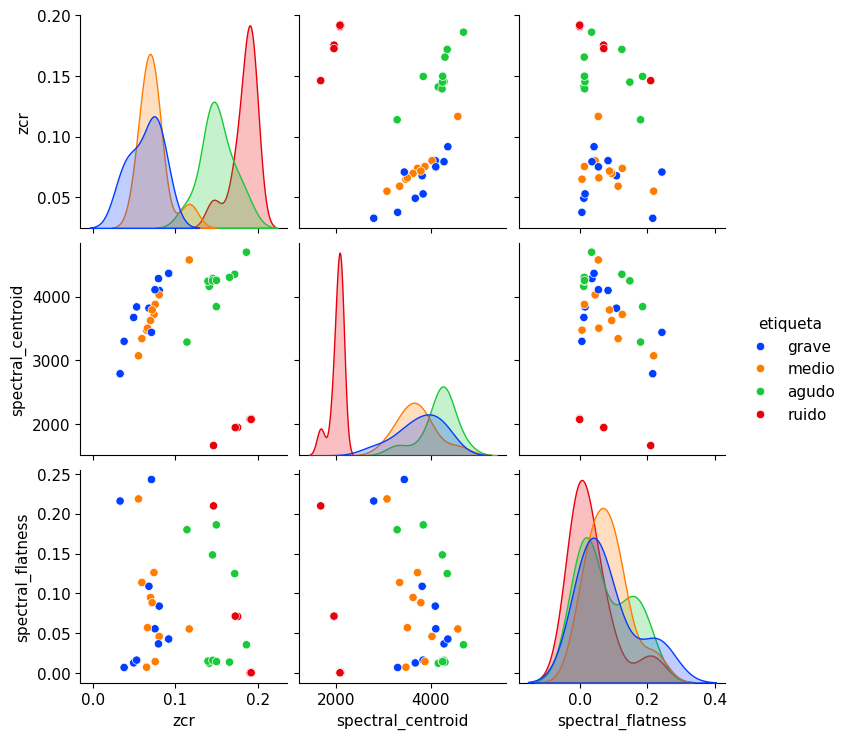

In [ ]:
# C.2. Pairplot de las 3 features más importantes (ZCR, Centroid, Flatness)
print("📈 Analizando la interacción entre las features más discriminativas...")
import warnings
warnings.filterwarnings('ignore') # Ignorar advertencias de densidad
top_3_features = ['zcr', 'spectral_centroid', 'spectral_flatness']
sns.pairplot(df_features, vars=top_3_features, hue='etiqueta', palette='bright', diag_kind='kde')
plt.show()

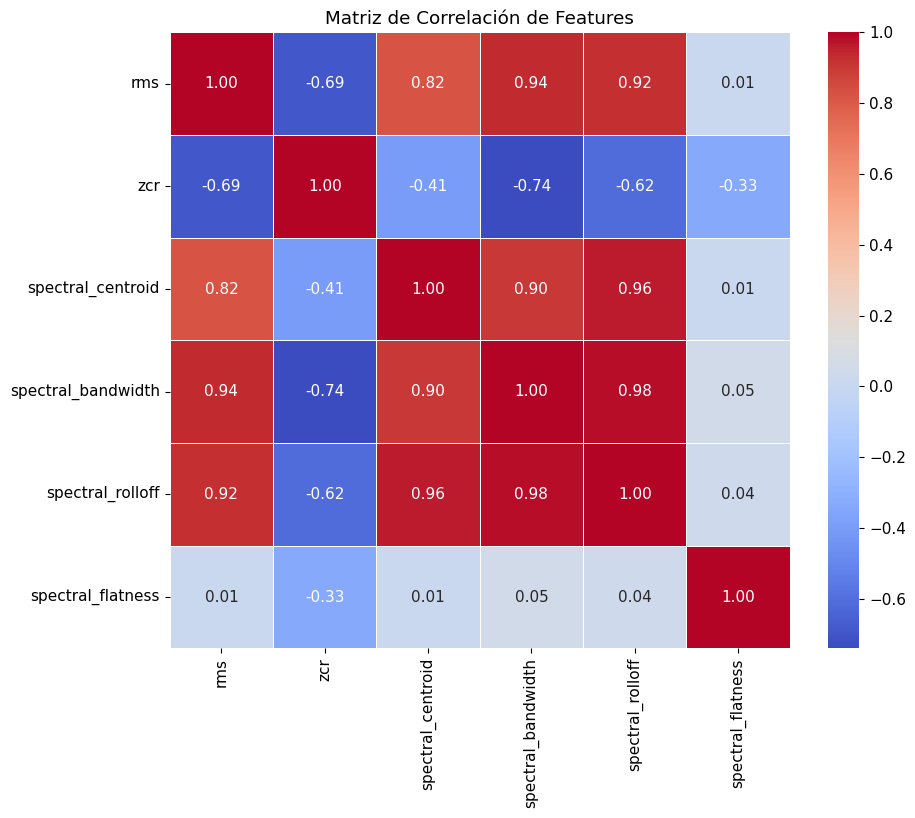

In [ ]:
# C.3. Heatmap de correlación
plt.figure(figsize=(10, 8))

# Excluimos columnas no numéricas para el cálculo
corr_matrix = df_features[cols_para_graficar].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación de Features")
plt.show()

### d) Análisis de correlación:
- Identificar pares defeatures con |correlación|>0.7
- Discutir redundancia

In [32]:
print("\n🔍 Análisis de Redundancia (|correlación| > 0.7):")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
pares_altos = [(column, row, upper_tri.loc[row, column])
               for column in upper_tri.columns
               for row in upper_tri.index
               if abs(upper_tri.loc[row, column]) > 0.7]

for f1, f2, val in pares_altos:
    print(f" - {f1} y {f2}: {val:.2f}")

print("\nDiscusión de redundancia: Existe una correlación muy alta entre el centroide espectral, "
      "\nel ancho de banda y el rolloff, ya que todos describen la distribución de energía en frecuencia. "
      "\nSe destaca además que el RMS presenta correlaciones altas con estas tres features "
      "\n(0.82, 0.94 y 0.92 respectivamente), lo que sugiere que con el ruido filtrado "
      "\nla energía promedio quedó más relacionada con el contenido frecuencial. "
      "\nSe detecta además una correlación negativa entre spectral_bandwidth y ZCR (-0.74), "
      "\nlo que indica que a mayor ancho de banda, menor tasa de cruces por cero, "
      "\nconsistente con el comportamiento del ruido filtrado. "
      "\nPara modelos simplificados, se podría mantener solo el Centroide Espectral "
      "\neliminando el bandwidth y el rolloff por su alta redundancia.")


🔍 Análisis de Redundancia (|correlación| > 0.7):
 - spectral_centroid y rms: 0.82
 - spectral_bandwidth y rms: 0.94
 - spectral_bandwidth y zcr: -0.74
 - spectral_bandwidth y spectral_centroid: 0.90
 - spectral_rolloff y rms: 0.92
 - spectral_rolloff y spectral_centroid: 0.96
 - spectral_rolloff y spectral_bandwidth: 0.98

Discusión de redundancia: Existe una correlación muy alta entre el centroide espectral, 
el ancho de banda y el rolloff, ya que todos describen la distribución de energía en frecuencia. 
Se destaca además que el RMS presenta correlaciones altas con estas tres features 
(0.82, 0.94 y 0.92 respectivamente), lo que sugiere que con el ruido filtrado 
la energía promedio quedó más relacionada con el contenido frecuencial. 
Se detecta además una correlación negativa entre spectral_bandwidth y ZCR (-0.74), 
lo que indica que a mayor ancho de banda, menor tasa de cruces por cero, 
consistente con el comportamiento del ruido filtrado. 
Para modelos simplificados, se podría m

### e) PCA:
- Aplicar PCA con 2 componentes principales
- Graficar proyección 2D coloreando por clase
- Calcular varianza explicada
- Evaluar si las clases están separables

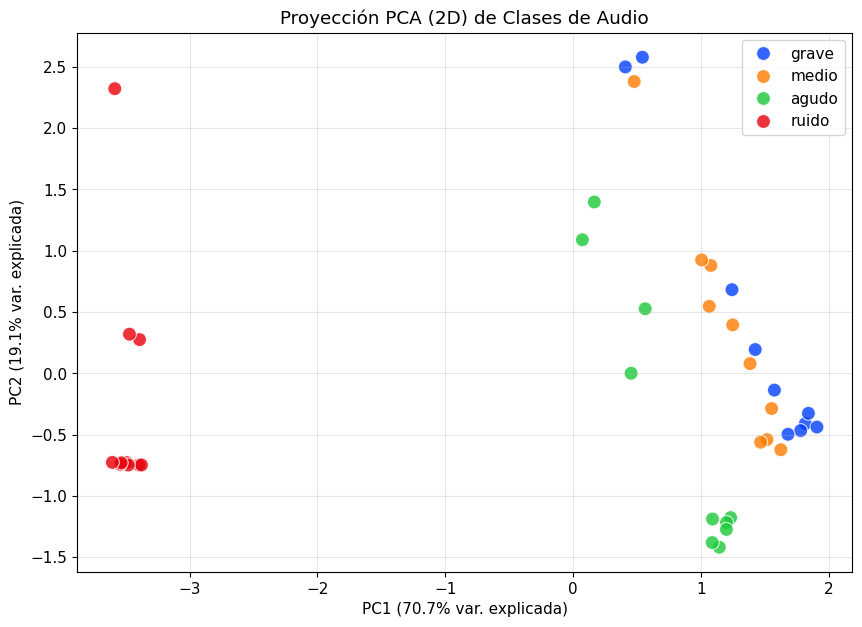

Varianza total explicada por 2 componentes: 89.82%


In [ ]:
# Preparar datos para PCA
X = df_features[cols_para_graficar]
X_scaled = StandardScaler().fit_transform(X)

# Aplicar PCA con 2 componentes
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)
df_features['pca_1'] = pca_results[:, 0]
df_features['pca_2'] = pca_results[:, 1]

# Graficar Proyección 2D
plt.figure(figsize=(10, 7))
sns.scatterplot(x='pca_1', y='pca_2', hue='etiqueta', data=df_features,
                s=100, alpha=0.8, palette='bright')
plt.title("Proyección PCA (2D) de Clases de Audio")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var. explicada)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var. explicada)")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Varianza total explicada por 2 componentes: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

### f) Conclusiones sobre separabilidad de clases

<br>

1. **Separabilidad:** Las clases son altamente separables en el espacio de características.
El gráfico de PCA muestra que el ruido está claramente separado
a la izquierda (PC1 negativo), mientras que las clases tonales
se distribuyen a la derecha. Dentro de las clases tonales hay
solapamiento entre grave, medio y agudo, por lo que PC1 sola
no las separa linealmente de forma perfecta. PC2 ayuda a
distribuirlas verticalmente..

2. **Fidelidad de Features:** - El **Zero Crossing Rate (ZCR)** y la **Spectral Flatness** son los mejores indicadores
     para identificar la clase 'ruido'.
   - El **Spectral Centroid** es el feature clave para distinguir entre las clases tonales.

3. **Varianza:** PC1 explica el 70.7% y PC2 el 19.1%, sumando un total de 89.8%
de la varianza explicada, lo que valida que la reducción de
dimensionalidad no genera una pérdida significativa de
información para este dataset sintético.


-------------------------------------------------------------



**RECURSOS Y BIBLIOGRAFÍA**
- https://stackoverflow.com/questions/14058340/adding-noise-to-a-signal-in-python
- https://stackoverflow.com/questions/51576875/snr-of-original-signal-and-quantized-signal-matlab
